# About Dataset

## Data Science Job Salaries Dataset contains 11 columns, each are:
    - work_year: The year the salary was paid.
    - experience_level: The experience level in the job during the year
    - employment_type: The type of employment for the role
    - job_title: The role worked in during the year.
    - salary: The total gross salary amount paid.
    - salary_currency: The currency of the salary paid as an ISO 4217 currency code.
    - salaryinusd: The salary in USD
    - employee_residence: Employee's primary country of residence in during the work year as an ISO 3166 country code.
    - remote_ratio: The overall amount of work done remotely
    - company_location: The country of the employer's main office or contracting branch
    - company_size: The median number of people that worked for the company during the year


In [1]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
job_salary = pd.read_csv(filepath_or_buffer='./datasets/ds_salaries.csv')
job_salary.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
job_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [4]:
job_salary.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [5]:
job_salary.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [6]:
job_salary.duplicated().value_counts()

False    2584
True     1171
Name: count, dtype: int64

In [7]:
job_salary.drop_duplicates(inplace=True)
job_salary.shape

(2584, 11)

In [8]:
job_salary.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


# EDA for the given data


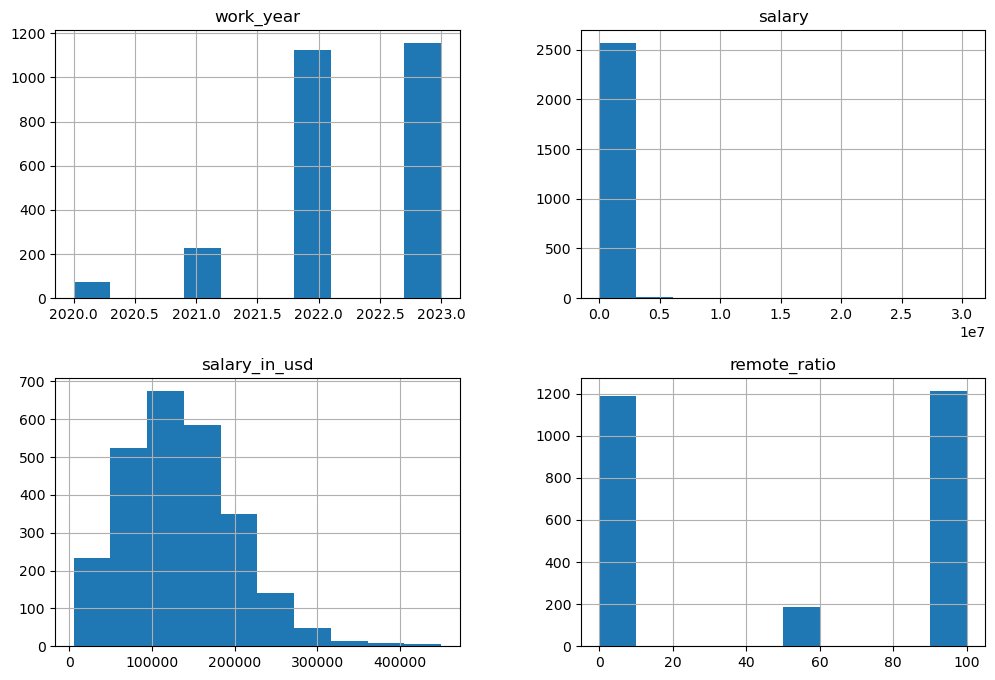

In [9]:
job_salary.hist(grid=True , figsize=(12,8))
plt.show()

----------------------
## Initial analysis
- observe columns **salary , salary_currency , salary_in_usd**
- we can make out that salary salary_currency combined give us the same info as salary_in_usd
- salary_in_usd is standard format for every role.

    - so we will drop salary and salary_currency.

In [10]:
job_salary.drop(columns=["salary" , "salary_currency"] , inplace=True , axis=1)
job_salary.shape

(2584, 9)

In [11]:
job_salary.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,CA,100,CA,M


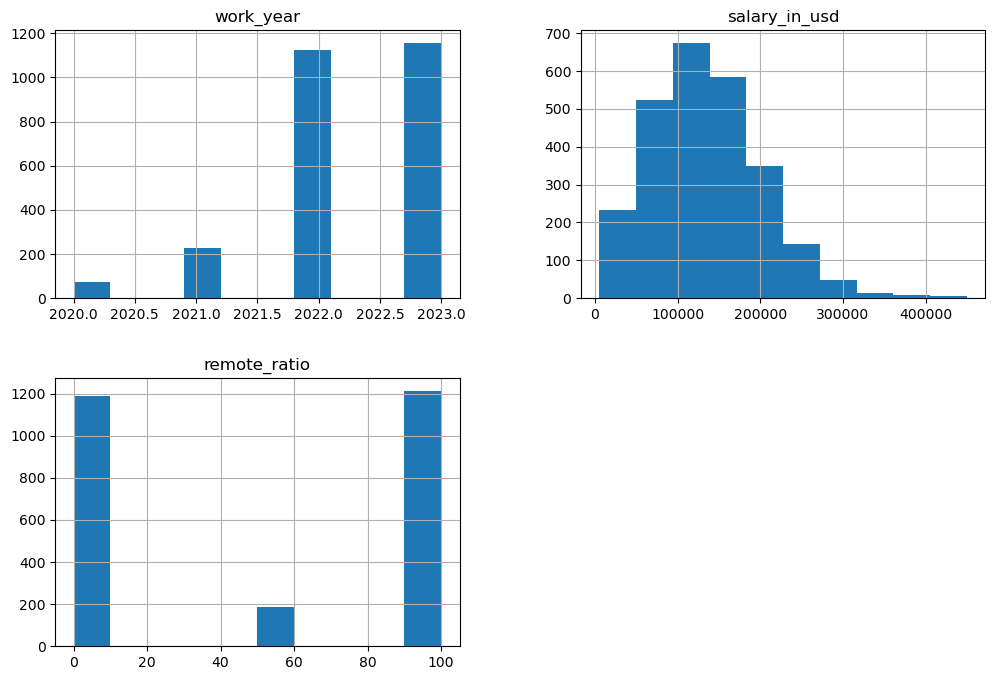

In [12]:
job_salary.hist(grid=True , figsize=(12,8))
plt.show()

In [13]:
job_salary.describe()

,work_year,salary_in_usd,remote_ratio
count,2584.000000,2584.000000,2584.000000
mean,2022.301084,133409.280186,50.483746
std,0.749179,67136.837329,48.163707
min,2020.000000,5132.000000,0.000000
25%,2022.000000,84975.000000,0.000000
50%,2022.000000,130000.000000,50.000000
75%,2023.000000,175000.000000,100.000000
max,2023.000000,450000.000000,100.000000


## - we are trying to build a classification model and learn the workflow of it.
### - but the dataset label i.e salary_in_usd is continous and not suitable for classification.
### - hence we need to transform this into a multi-class classification problem.
        - the salary range from (5132 - 450000) USD.
        - let us divide this into 4 classes.
                - "low" -> salary <= 70000.
                - "avg" -> 70000 < salary >= 150000
                - "above_avg" -> 150000 < salary >= 250000
                - "high" -> salary >= 250000

In [14]:
job_salary["label_class"] = pd.cut(job_salary["salary_in_usd"] , bins=(0,70000 , 150000 , 250000 , np.inf) , labels=["low" , "avg" , "above_avg" , "high"])
job_salary.drop(columns=["salary_in_usd"] , inplace=True , axis=1)
job_salary.head()

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,label_class
0,2023,SE,FT,Principal Data Scientist,ES,100,ES,L,avg
1,2023,MI,CT,ML Engineer,US,100,US,S,low
2,2023,MI,CT,ML Engineer,US,100,US,S,low
3,2023,SE,FT,Data Scientist,CA,100,CA,M,above_avg
4,2023,SE,FT,Data Scientist,CA,100,CA,M,avg


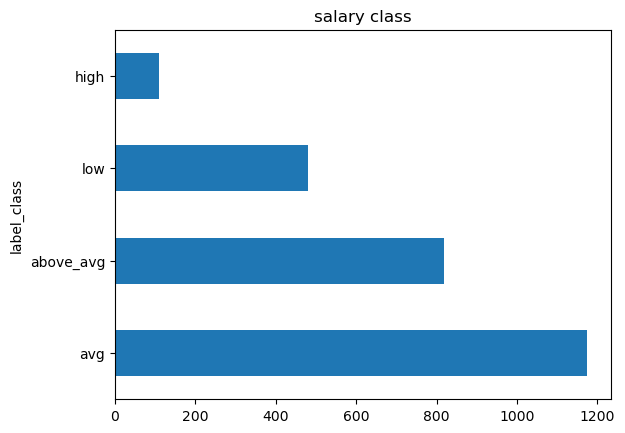

In [15]:
job_salary["label_class"].value_counts().plot(kind="barh")
plt.title("salary class")
plt.show()

In [16]:
job_salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           2584 non-null   int64   
 1   experience_level    2584 non-null   object  
 2   employment_type     2584 non-null   object  
 3   job_title           2584 non-null   object  
 4   employee_residence  2584 non-null   object  
 5   remote_ratio        2584 non-null   int64   
 6   company_location    2584 non-null   object  
 7   company_size        2584 non-null   object  
 8   label_class         2584 non-null   category
dtypes: category(1), int64(2), object(6)
memory usage: 184.4+ KB


In [17]:
job_salary.dtypes.value_counts()

object      6
int64       2
category    1
Name: count, dtype: int64

-----------------------------------------
### now let's deal with object type datatype
- there are 6 object type and 1 categorical column.

----------------------------
list of techniques that can be used for dealing with object type
1. Target Encoding :
This method involves encoding the categorical variable with the mean of the target variable (e.g., salary) for each category.

2. Frequency Encoding :
Encode categories based on the frequency of their occurrence.

3. Embedding :
Using embeddings for categorical variables can be useful, especially in deep learning models.

4. Hashing :
The feature hashing (or the hashing trick) is a way to transform categorical data into a fixed-size vector.

5. Reducing Cardinality :
Combining rare categories into a single "Other" category can help reduce the number of unique values.

In [18]:
job_salary.select_dtypes("object").nunique().sort_values()

company_size           3
experience_level       4
employment_type        4
company_location      72
employee_residence    78
job_title             93
dtype: int64

#### as we can see that there are few unque values in 1st 3 columns listed above
- we can use label encoding for these

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply Label Encoding to the specified columns
job_salary['experience_level'] = le.fit_transform(job_salary['experience_level'])
job_salary['employment_type'] = le.fit_transform(job_salary['employment_type'])
job_salary['company_size'] = le.fit_transform(job_salary['company_size'])

job_salary['label_class'] = le.fit_transform(job_salary['label_class'])

In [20]:
job_salary.head()

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,label_class
0,2023,3,2,Principal Data Scientist,ES,100,ES,0,1
1,2023,2,0,ML Engineer,US,100,US,2,3
2,2023,2,0,ML Engineer,US,100,US,2,3
3,2023,3,2,Data Scientist,CA,100,CA,1,0
4,2023,3,2,Data Scientist,CA,100,CA,1,1


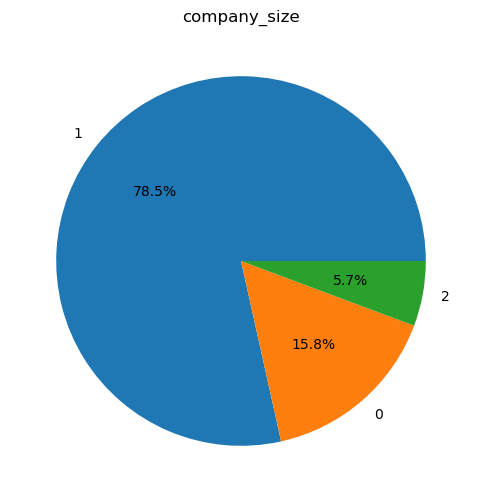

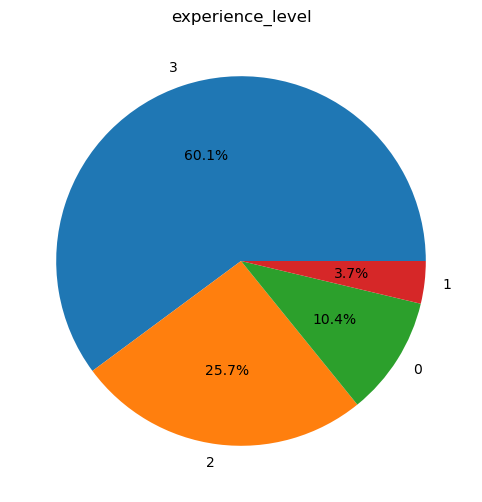

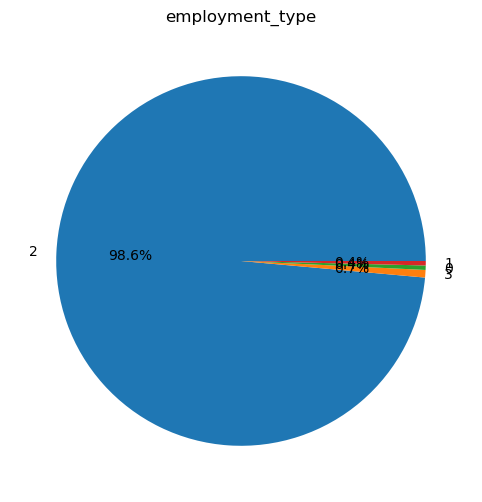

In [21]:
pie_cols = ["company_size","experience_level" , "employment_type"]

# Iterate over each object-type column
for col in pie_cols:
     # Get the value counts for the column
     vc = job_salary[col].value_counts()

     # Plot a pie chart
     plt.figure(figsize=(8,6))
     plt.pie(vc, labels=vc.index, autopct='%1.1f%%')
     plt.title(col)
     plt.show()

#### for the other columns that has more unique values , we cannot use OneHotEncodder or label_encoder
#### these encodings put us to High-Dimentionality pool

- to over come this we will use combination of Grouping and Frequency Encoding.
- This approach will reduce the number of categories while still preserving some information about the relative importance of each category.

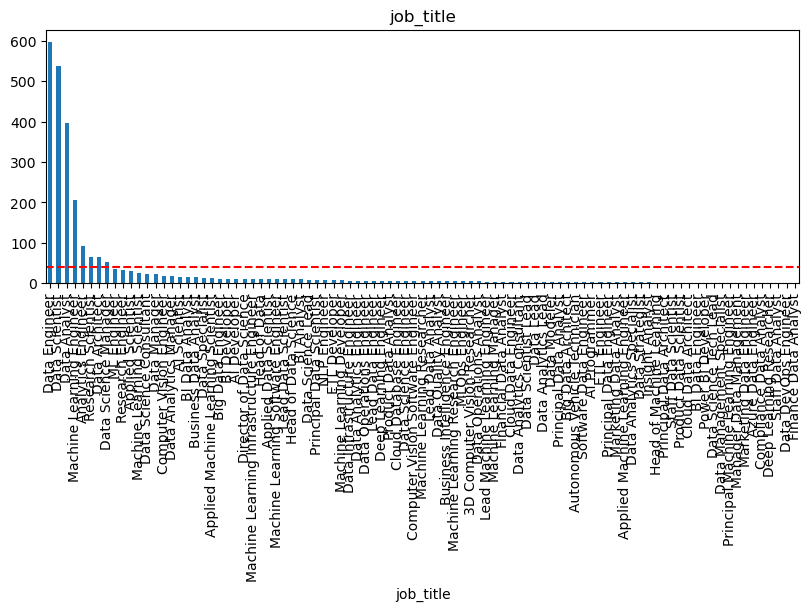

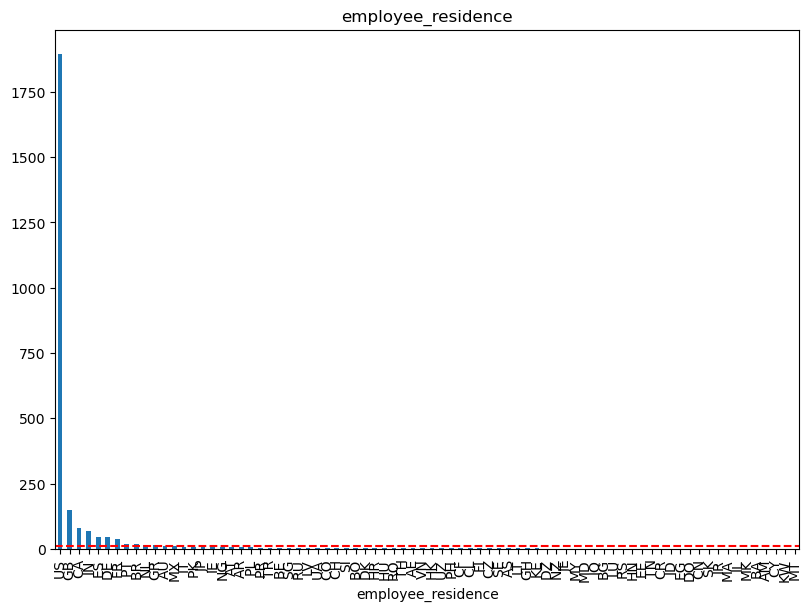

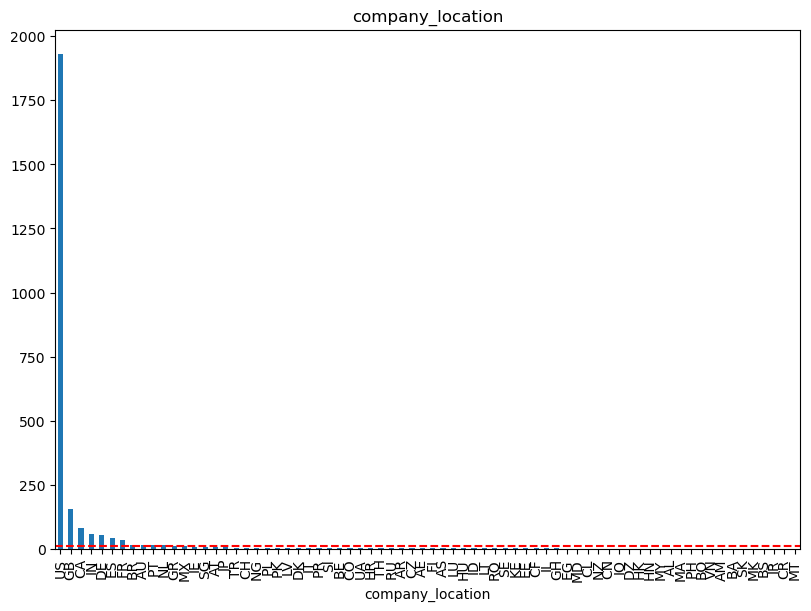

In [22]:
bar_col = [ 'job_title' , 'employee_residence' ,'company_location']

for col in bar_col:
    vc = job_salary[col].value_counts()
    plt.figure(figsize=(8, 6), layout="constrained")
    vc.plot(kind='bar')
    if col == 'job_title':
        plt.axhline(y=40, color='r', linestyle='--')
    else:
        plt.axhline(y=10, color='r', linestyle='--')
    plt.title(col)
    plt.show()

In [23]:
def grouped_frequency_encoding(df, column, threshold=10):
    # Calculate frequency of each category
    freq = df[column].value_counts()
    
    # Identify categories to group
    mask = freq < threshold
    categories_to_group = freq[mask].index
    
    # Group infrequent categories
    df[column + '_grouped'] = df[column].replace(categories_to_group, 'Other')
    
    # Perform frequency encoding on grouped categories
    freq_grouped = df[column + '_grouped'].value_counts(normalize=True)
    df[column + '_freq'] = df[column + '_grouped'].map(freq_grouped)
    
    # Label encode the grouped categories
    le = LabelEncoder()
    df[column + '_label'] = le.fit_transform(df[column + '_grouped'])
    
    return df


In [24]:
# Assuming your dataframe is called 'df'
job_salary = grouped_frequency_encoding(job_salary, 'job_title', threshold=40)
job_salary = grouped_frequency_encoding(job_salary, 'employee_residence', threshold=10)
job_salary = grouped_frequency_encoding(job_salary, 'company_location', threshold=10)

In [25]:
job_salary.head()

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,label_class,job_title_grouped,job_title_freq,job_title_label,employee_residence_grouped,employee_residence_freq,employee_residence_label,company_location_grouped,company_location_freq,company_location_label
0,2023,3,2,Principal Data Scientist,ES,100,ES,0,1,Other,0.222136,7,ES,0.018189,4,ES,0.017028,4
1,2023,2,0,ML Engineer,US,100,US,2,3,Other,0.222136,7,US,0.732585,13,US,0.746517,13
2,2023,2,0,ML Engineer,US,100,US,2,3,Other,0.222136,7,US,0.732585,13,US,0.746517,13
3,2023,3,2,Data Scientist,CA,100,CA,1,0,Data Scientist,0.208204,5,CA,0.031347,2,CA,0.032121,2
4,2023,3,2,Data Scientist,CA,100,CA,1,1,Data Scientist,0.208204,5,CA,0.031347,2,CA,0.032121,2


In [26]:
obj_col = job_salary.select_dtypes(["object"]).columns.to_list()
job_salary.drop(columns=obj_col , inplace=True , axis=1)
job_salary.head()

,work_year,experience_level,employment_type,remote_ratio,company_size,label_class,job_title_freq,job_title_label,employee_residence_freq,employee_residence_label,company_location_freq,company_location_label
0,2023,3,2,100,0,1,0.222136,7,0.018189,4,0.017028,4
1,2023,2,0,100,2,3,0.222136,7,0.732585,13,0.746517,13
2,2023,2,0,100,2,3,0.222136,7,0.732585,13,0.746517,13
3,2023,3,2,100,1,0,0.208204,5,0.031347,2,0.032121,2
4,2023,3,2,100,1,1,0.208204,5,0.031347,2,0.032121,2


# now all the feature and label is transformed to numeric

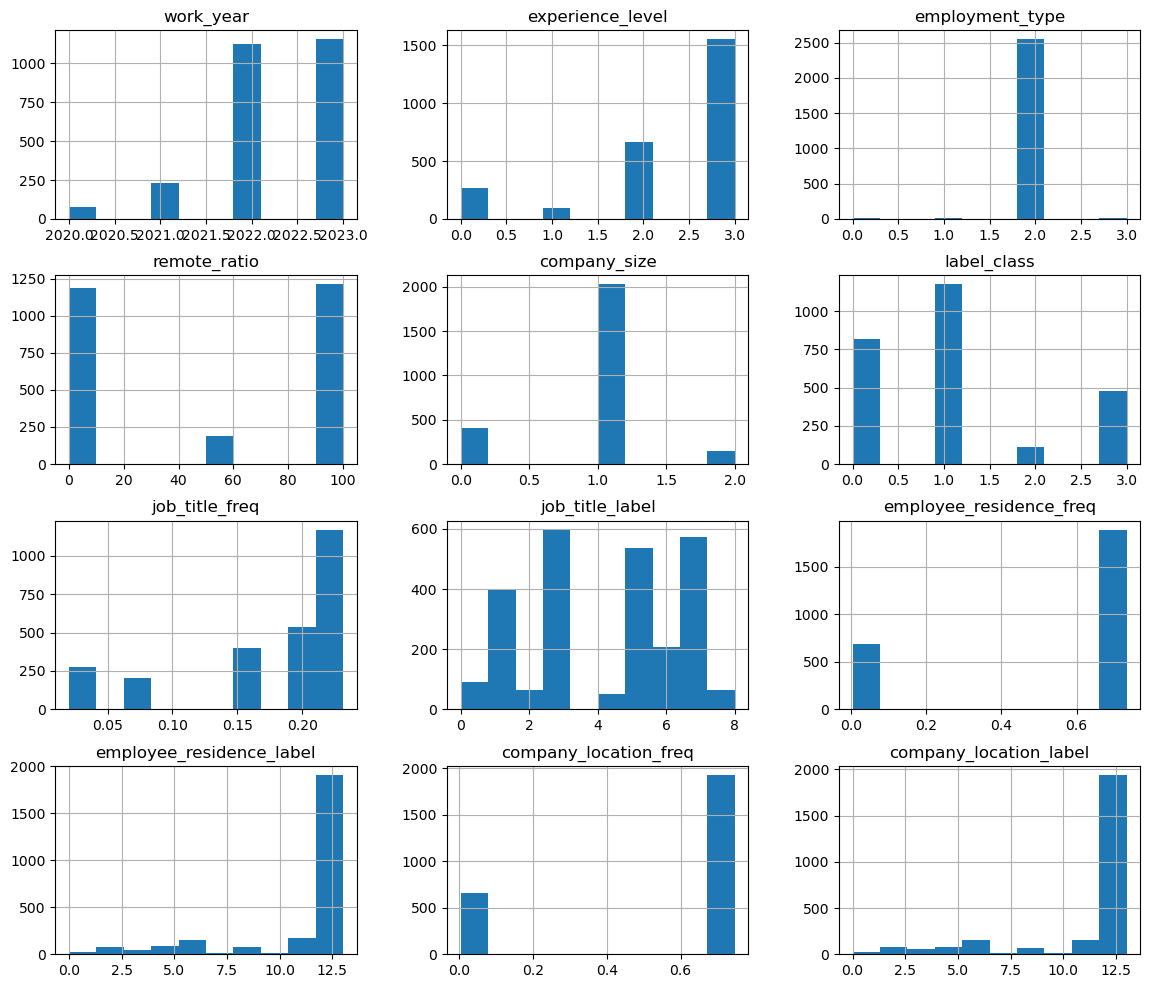

In [31]:
job_salary.hist(figsize=(14,12))
plt.show()

In [36]:
job_salary.corrwith(job_salary["label_class"]).sort_values(ascending=False)

label_class                 1.000000
remote_ratio                0.068631
job_title_freq              0.067142
job_title_label             0.029307
company_size               -0.003721
employment_type            -0.024694
work_year                  -0.226116
experience_level           -0.373852
company_location_label     -0.380288
employee_residence_label   -0.386151
company_location_freq      -0.516461
employee_residence_freq    -0.538743
dtype: float64

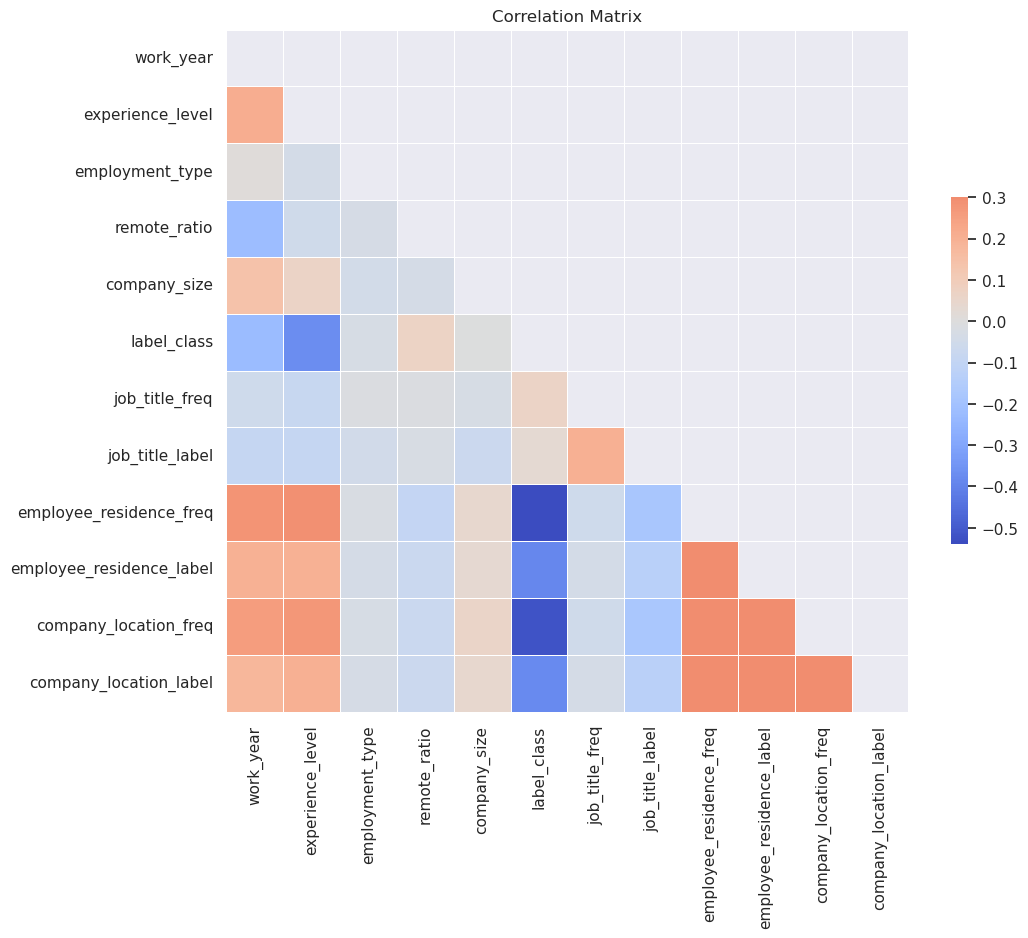

In [53]:
# Calculate the correlation matrix
corr_matrix = job_salary.corr()

# Plot the correlation matrix using seaborn
sns.set(style="dark")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title("Correlation Matrix")
plt.show()

# now its time to build the pipeline for preprocessing 

In [41]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer , StandardScaler
from sklearn.impute import SimpleImputer

In [75]:
log_pipeline = make_pipeline(SimpleImputer(strategy="mean"),
                             FunctionTransformer(np.log , inverse_func=np.exp ,
                            feature_names_out="one-to-one")
                            )

num_pipeline = make_pipeline(SimpleImputer(strategy="mean") , StandardScaler())

In [76]:
preprocessing = ColumnTransformer([
    ("year" , log_pipeline , ["work_year"]),
    ("numeric" , num_pipeline , job_salary.select_dtypes(["object"]).columns.to_list())
] , remainder=num_pipeline)
preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('year',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log'>,
                                                                      inverse_func=<ufunc 'exp'>))]),
                                 ['work_year']),
                                ('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 [])])

In [77]:
preprocessing.fit_transform(X=job_salary.drop(columns=["label_class"]))

array([[  7.61233684,   0.66845688,   0.03125876, ...,  -2.20795708,
         -1.78250613,  -2.19372816],
       [  7.61233684,  -0.36833338, -12.39530127, ...,   0.51060761,
          0.58236356,   0.49990131],
       [  7.61233684,  -0.36833338, -12.39530127, ...,   0.51060761,
          0.58236356,   0.49990131],
       ...,
       [  7.61085279,  -2.4419139 ,   0.03125876, ...,   0.51060761,
          0.58236356,   0.49990131],
       [  7.61085279,  -2.4419139 , -12.39530127, ...,   0.51060761,
          0.58236356,   0.49990131],
       [  7.61134772,   0.66845688,   0.03125876, ...,  -0.9997061 ,
         -1.76619669,  -0.99655951]])

In [78]:
preprocessing.get_feature_names_out()

array(['year__work_year', 'remainder__experience_level',
       'remainder__employment_type', 'remainder__remote_ratio',
       'remainder__company_size', 'remainder__job_title_freq',
       'remainder__job_title_label', 'remainder__employee_residence_freq',
       'remainder__employee_residence_label',
       'remainder__company_location_freq',
       'remainder__company_location_label'], dtype=object)

---------------
### lets split the dataset

In [79]:
from sklearn.model_selection import train_test_split

train_set , test_set = train_test_split(job_salary , test_size=0.2 , stratify=job_salary["work_year"] , shuffle=True , random_state=42)

In [80]:
train_set

,work_year,experience_level,employment_type,remote_ratio,company_size,label_class,job_title_freq,job_title_label,employee_residence_freq,employee_residence_label,company_location_freq,company_location_label
3342,2022,3,2,100,1,2,0.024768,2,0.732585,13,0.746517,13
489,2023,3,2,0,1,0,0.208204,5,0.732585,13,0.746517,13
1313,2023,3,2,100,1,0,0.208204,5,0.732585,13,0.746517,13
1909,2022,3,2,0,1,0,0.231424,3,0.732585,13,0.746517,13
2762,2022,3,2,100,1,0,0.079721,6,0.067337,11,0.058437,11
...,...,...,...,...,...,...,...,...,...,...,...,...
1901,2022,3,2,100,1,0,0.079721,6,0.732585,13,0.746517,13
810,2023,2,2,0,1,1,0.020124,4,0.732585,13,0.746517,13
1223,2023,0,2,100,0,3,0.153251,1,0.732585,13,0.746517,13
1676,2023,3,2,100,1,0,0.020124,4,0.732585,13,0.746517,13


In [81]:
test_set

,work_year,experience_level,employment_type,remote_ratio,company_size,label_class,job_title_freq,job_title_label,employee_residence_freq,employee_residence_label,company_location_freq,company_location_label
255,2023,3,2,0,1,0,0.222136,7,0.732585,13,0.746517,13
1497,2023,3,2,0,1,1,0.153251,1,0.732585,13,0.746517,13
2833,2022,1,2,100,1,2,0.231424,3,0.732585,13,0.746517,13
3149,2022,3,2,0,1,1,0.153251,1,0.732585,13,0.746517,13
2522,2022,1,2,100,1,0,0.035217,0,0.732585,13,0.746517,13
...,...,...,...,...,...,...,...,...,...,...,...,...
642,2023,3,2,100,1,1,0.024768,2,0.732585,13,0.746517,13
2011,2022,2,2,0,1,2,0.153251,1,0.058050,6,0.059985,6
1557,2023,3,2,100,1,1,0.222136,7,0.732585,13,0.746517,13
779,2023,3,2,100,1,2,0.222136,7,0.031347,2,0.032121,2


In [82]:
X_train = train_set.drop(columns=["label_class"])
y_train = train_set["label_class"]
X_test = test_set.drop(columns=["label_class"])
y_test = test_set["label_class"]

In [83]:
from sklearn.linear_model import LogisticRegression ,SGDClassifier
from sklearn.model_selection import cross_val_predict , cross_val_score
from sklearn.metrics import confusion_matrix , precision_score , recall_score , f1_score

In [84]:
LR_cls = make_pipeline(preprocessing , LogisticRegression(max_iter=1000))

LR_cls.fit(X=X_train , y=y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer()),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('year',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log'>,
                                                                                       inverse_func=<ufunc 'exp'>))]),
                                                  ['work_year']),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  [])])),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [85]:
cross_val_score(LR_cls , X_train , y=y_train , scoring="accuracy" , cv=10 ).mean()

0.5389053046292387

In [95]:
sgd_class = make_pipeline(preprocessing , 
                          SGDClassifier(loss="squared_error",penalty="elasticnet" , learning_rate="adaptive" ,eta0=0.01 , random_state=42))

sgd_class.fit(X=X_train , y=y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer()),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('year',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log'>,
                                                                                       inverse_func=<ufunc 'exp'>))]),
                                                  ['work_year']),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  [])])),
                ('sgdclassifier',
                 SGDClassifier(eta0=0.01, learning_rate='adaptive',
                               loss='squared_error', penalty='elasticnet',
                               random_state=42))])

In [99]:
cross_val_score(sgd_class , X_train , y=y_train , scoring="accuracy" , cv=10 ).mean()

0.523931804324375